# Planificación: Dyna-Q (TD)

- Estudiante 1: `Rodrigo Benitez - 172018`

En este notebook implementaremos el algoritmo Dyna-Q, que combina aprendizaje por refuerzo y planificación. Este enfoque utiliza la experiencia del agente para actualizar su modelo del entorno y luego simula experiencias adicionales basadas en ese modelo. Usaremos lo aprendido en Q-learning y lo compararemos con el algoritmo Dyna-Q.

## Objetivos

- Implementar el algoritmo Dyna-Q.
- Comparar el rendimiento de Dyna-Q con Q-learning.
- Aplicarlo en otro entorno de OpenAI Gymmnasium (a elección del estudiante).

## Descripción del Ambiente: MountainCar

El entorno [**MountainCar**](https://gymnasium.farama.org/environments/classic_control/mountain_car/) es un clásico problema de control utilizado en el ámbito del Reinforcement Learning. En este escenario, un automóvil se encuentra atrapado en un valle estrecho entre dos colinas y debe aprender a alcanzar la cima de la montaña de la derecha. Debido a las limitaciones físicas, el coche no puede simplemente acelerar de forma continua hacia la cima; en cambio, debe aprovechar la inercia y la gravedad para acumular suficiente impulso.

**Espacio de Estados**

El estado del entorno se define mediante dos variables continuas:
- **Posición:** Indica la ubicación actual del automóvil sobre la pista, con un rango aproximado de \[-0.6, 0.4\].
- **Velocidad:** Representa la velocidad del automóvil, y comienza siempre en 0.

**Acciones Disponibles**

El agente dispone de tres acciones discretas:
- **[0] Empujar a la izquierda:** Aplica una fuerza que impulsa el coche hacia la izquierda.
- **[1] No hacer nada:** No se aplica ninguna fuerza, permitiendo que la dinámica natural del coche influya en el movimiento.
- **[2] Empujar a la derecha:** Aplica una fuerza que impulsa el coche hacia la derecha.

**Mecánica y Dinámica del Problema**

El desafío principal no radica únicamente en acelerar hacia la derecha. Debido a la gravedad y las limitaciones del motor del coche, para lograr alcanzar la cima de la montaña es necesario **aprovechar la inercia**. Esto implica que, en muchos casos, el coche debe moverse hacia la izquierda para ganar impulso y luego aprovechar esa energía para impulsarse con mayor fuerza hacia la derecha, logrando finalmente superar la pendiente.

**Función de Recompensa**

En cada paso del tiempo, el agente recibe una recompensa constante de **-1**. Esta penalización por cada paso incentiva al agente a encontrar la estrategia óptima que le permita alcanzar la cima de la montaña en la menor cantidad de pasos posible. Al llegar a la meta (generalmente cuando la posición del coche alcanza o supera un valor umbral, 0.5), el episodio se termina.


![MountainCar](https://gymnasium.farama.org/_images/mountain_car.gif)


In [1]:
import gymnasium as gym
from gymnasium.utils.play import play
from gymnasium.wrappers import RecordVideo, TransformObservation
from gymnasium import spaces
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from Utils import plot_rewards, plot_epsilon, plot_rewards_comparison, random_argmax
from IPython.display import Video
%matplotlib inline

In [2]:
import os

if os.name == 'posix' and os.uname().sysname == 'Darwin':
    # Set the path to ffmpeg for macOS, replace with your actual path
    os.environ["IMAGEIO_FFMPEG_EXE"] = "/opt/homebrew/bin/ffmpeg"

In [3]:
def get_env(record_video=False, record_every=1, folder="./videos" ):
    """
    Create the MountainCar environment with optional video recording and statistics.
    Args:
        record_video (bool): Whether to record video of the episodes.
        record_every (int): Frequency of recording episodes.
        folder (str): Folder to save the recorded videos.
    Returns:
        env (gym.Env): The MountainCar environment.
        
    See also:
        https://gymnasium.farama.org/introduction/record_agent/
    """
    # Initialise the environment
    env = gym.make("MountainCar-v0", render_mode="rgb_array")

    if record_video:
        env = RecordVideo(env, video_folder=folder, name_prefix="MountainCar",
                    episode_trigger=lambda x: x % record_every == 0,
                    disable_logger=True)
    
    return env

In [4]:
env = get_env(record_video=True, record_every=1, folder="./videos/random_actions")

for episode_num in range(5):
    obs, info = env.reset()

    episode_over = False
    while not episode_over:
        action = env.action_space.sample()  # Random action
        obs, reward, terminated, truncated, info = env.step(action)
        episode_over = terminated or truncated

/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/rodrigobenitez/Documents/GitHub/ORT-AI/Taller Inteligencia Artificial/Clases/Laboratorio 6 - Dyna-Q/videos/random_actions folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### Uso de `TransformObservation` para Discretizar el Ambiente

Gymnasium ofrece un wrapper muy práctico llamado `TransformObservation` que permite transformar las observaciones de manera sencilla sin necesidad de definir una clase personalizada. Esto es especialmente útil cuando se quiere convertir un espacio continuo en un espacio discreto para poder utilizar métodos tabulares como Q-Learning o Sarsa.

Ver [TransformObservation](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.TransformObservation) para más detalles.

In [5]:
NUMBER_STATES = 50

def make_discretizer(low, high, n_bins):
    """Devuelve una función que mapea (pos, vel) continuos a índices [0, n_bins-1]."""
    den = (high - low) / n_bins

    def discretize_obs(obs):
        # Clip evita índices fuera de rango cuando obs == high.
        scaled = ((obs - low) / den).astype(int)
        scaled = np.clip(scaled, 0, n_bins - 1)
        return int(scaled[0]), int(scaled[1])

    return discretize_obs

In [6]:
def get_env_discretized(record_video=False, record_every=1, folder="./videos"):
    base_env = get_env(record_video=record_video, record_every=record_every, folder=folder)
    discretize_obs = make_discretizer(base_env.observation_space.low,
                                      base_env.observation_space.high,
                                      NUMBER_STATES)
    new_observation_space = spaces.MultiDiscrete([NUMBER_STATES, NUMBER_STATES])
    return TransformObservation(base_env, discretize_obs, new_observation_space)

In [7]:
env = get_env()
obs, info = env.reset()
print(f"Original observation: {obs}")

env_dis = get_env_discretized()
obs, info = env_dis.reset()
print(f"Discretized observation: {obs}")

Original observation: [-0.4746265  0.       ]
Discretized observation: (21, 25)


/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


## Q-Learning
Q-Learning es un algoritmo de aprendizaje por refuerzo que busca aprender la función de valor óptima $Q^*(s, a)$ para cada par de estado-acción. A través de la exploración y explotación, el agente actualiza su tabla Q utilizando el siguiente algoritmo:

$$
\begin{aligned}
\textbf{Q-Learning (Off-Policy TD Control)} \\[6pt]
\textbf{Parámetros:} & \quad \alpha \in (0,1],\ \varepsilon > 0,\ \gamma \in (0,1].\\[6pt]
\textbf{Inicializar:} & \quad Q(s,a)\ \text{arbitrario para } s \in S,\ a \in A(s), \\
& \quad Q(\text{terminal},\cdot) = 0.\\[6pt]
\textbf{Loop (por cada episodio):} & \\[-2pt]
& \quad \text{Inicializar } S.\\
& \quad \textbf{mientras } S \text{ no sea terminal:}\\
& \quad\quad A \leftarrow \text{acción seleccionada a partir de } S \text{ usando política } \varepsilon\text{-greedy con respecto a } Q.\\
& \quad\quad \text{Ejecutar } A,\ \text{observar } R,\ S'.\\
& \quad\quad Q(S,A) \leftarrow Q(S,A) \;+\; \alpha \Bigl[\,R \;+\; \gamma \max_{a \in A(S')}Q(S',a) \;-\; Q(S,A)\Bigr]\\
& \quad\quad S \leftarrow S'.\\
\end{aligned}
$$


In [8]:
def select_action(env, Q, pos, vel, epsilon):
    """Politica epsilon-greedy con desempate aleatorio uniforme.

    - Con probabilidad epsilon explora: accion uniforme en A(s).
    - Con probabilidad 1 - epsilon explota: argmax_a Q(s,a).

    Args:
        env     : ambiente Gymnasium (se usa env.action_space.sample()).
        Q       : tabla de valores, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        pos, vel: indices discretos del estado actual.
        epsilon : probabilidad de explorar, en [0, 1].

    Returns:
        action (int): indice de la accion seleccionada en {0, ..., n_actions - 1}.
    """
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return random_argmax(Q[pos, vel])

In [9]:
def q_learning(env, num_episodes=1000, alpha=0.1, gamma=0.99,
               epsilon_start=1.0, epsilon_decay=0.9995, epsilon_min=0.05):
    """
    Q-learning (Sutton & Barto, sec. 6.5).

    Args:
        env          : ambiente discretizado (estado = (pos, vel) en {0,...,NUMBER_STATES-1}^2).
        num_episodes : cantidad de episodios de entrenamiento.
        alpha        : tasa de aprendizaje, en (0, 1].
        gamma        : factor de descuento, en (0, 1].
        epsilon_start: epsilon inicial (mas exploracion).
        epsilon_decay: factor multiplicativo aplicado por episodio.
        epsilon_min  : piso de epsilon (no decae por debajo).

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio (largo num_episodes).
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((NUMBER_STATES, NUMBER_STATES, env.action_space.n))
    epsilon = epsilon_start
    episode_rewards, epsilons = [], []

    pbar = tqdm(range(num_episodes), desc="Q-Learning")
    for ep in pbar:
        (pos, vel), _ = env.reset()
        done = False
        episode_reward = 0.0
        while not done:
            action = select_action(env, Q, pos, vel, epsilon)
            (next_pos, next_vel), reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward

            # Target off-policy: max_a Q(S', a)
            td_target = reward + gamma * np.max(Q[next_pos, next_vel])
            Q[pos, vel, action] += alpha * (td_target - Q[pos, vel, action])

            pos, vel = next_pos, next_vel
            done = terminated or truncated

        episode_rewards.append(episode_reward)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep + 1) % 50 == 0:
            recent = np.mean(episode_rewards[-100:])
            pbar.set_postfix(reward=f"{recent:.1f}", eps=f"{epsilon:.3f}")

    return Q, episode_rewards, epsilons

In [10]:
NUMBER_EPISODES = 30_000

env_dis = get_env_discretized(record_video=True, record_every=5_000, folder="./videos/q_learning_training")
Q_ql, rewards_ql, epsilons_ql = q_learning(env_dis, num_episodes=NUMBER_EPISODES)

/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/rodrigobenitez/Documents/GitHub/ORT-AI/Taller Inteligencia Artificial/Clases/Laboratorio 6 - Dyna-Q/videos/q_learning_training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
Q-Learning: 100%|██████████| 30000/30000 [01:43<00:00, 289.82it/s, eps=0.050, reward=-153.1]


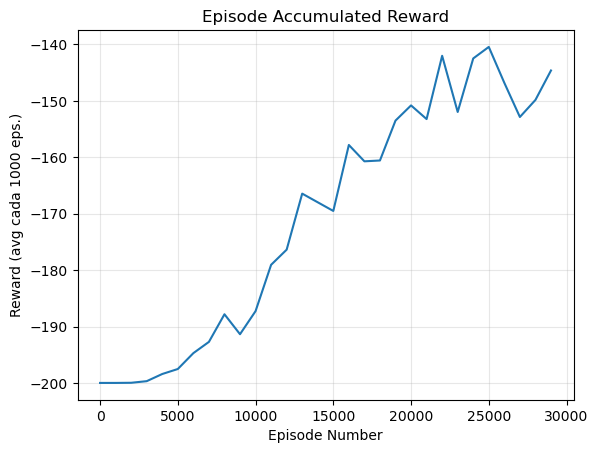

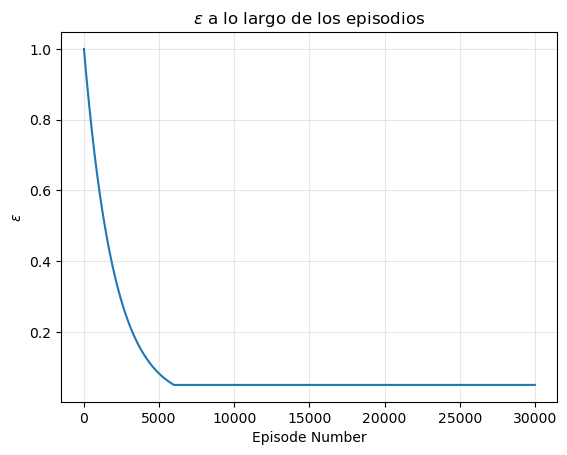

In [11]:
plot_rewards(rewards_ql)
plot_epsilon(epsilons_ql)

In [12]:
Q_LEARNING_VIDEO_TEST = "./videos/q_learning_test"
env_dis = get_env_discretized(record_video=True, record_every=1, folder=Q_LEARNING_VIDEO_TEST)

for episode_num in range(5):
    (pos, vel), info = env_dis.reset()
    episode_over = False
    while not episode_over:
        action = np.argmax(Q_ql[pos, vel])  # Exploit
        (pos, vel), reward, terminated, truncated, info = env_dis.step(action)
        episode_over = terminated or truncated

/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/rodrigobenitez/Documents/GitHub/ORT-AI/Taller Inteligencia Artificial/Clases/Laboratorio 6 - Dyna-Q/videos/q_learning_test folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [13]:
# Ruta al archivo de vídeo en tu sistema de ficheros
video_path = Q_LEARNING_VIDEO_TEST + "/MountainCar-episode-0.mp4"

# Muestra el vídeo
Video(video_path, embed=True, width=600)

## Dyna-Q

Dyna-Q es un algoritmo que combina el aprendizaje por refuerzo con la planificación. Utiliza la experiencia del agente para actualizar su modelo del entorno y luego simula experiencias adicionales basadas en ese modelo. Esto permite al agente aprender de manera más eficiente al combinar la exploración del entorno real con la explotación de un modelo aprendido.

Preguntas clave que responderemos:
- ¿Cómo modelamos el entorno?
- ¿Cómo actualizamos el modelo del entorno?
- ¿Cómo generamos experiencias simuladas?

$$
\begin{aligned}
\textbf{Dyna-Q (Control TD Off-Policy con Planificación)} \\[6pt]
\textbf{Parámetros:} &\quad \alpha \in (0,1],\;\varepsilon > 0,\;\gamma \in (0,1],\;n \in \mathbb{N}.\\[6pt]
\textbf{Inicializar:} 
&\quad Q(s,a)\;\text{arbitrario para todo }s \in S,\;a \in A(s),\\
&\quad Q(\text{terminal},\cdot) = 0,\\
&\quad \text{Modelo vacío: } Model(s,a)\;\text{indica transición no observada}.\\[6pt]
\textbf{Loop (por cada episodio):} &\\
&\quad \text{Inicializar } S.\\
&\quad \textbf{mientras } S \text{ no sea terminal:}\\
&\quad\quad A \;\leftarrow\; \text{acción seleccionada con política } \varepsilon\text{-greedy respecto a }Q(S,\cdot).\\
&\quad\quad \text{Ejecutar } A,\;\text{observar } R,\;S'.\\
&\quad\quad Q(S,A) \;\leftarrow\; Q(S,A)\;+\;\alpha\,\bigl[\;R \;+\;\gamma\,\max_{a\in A(S')}Q(S',a)\;-\;Q(S,A)\bigr]\\
&\quad\quad \text{Actualizar modelo: } Model(S,A)\;\leftarrow\;(R,\,S').\\
&\quad\quad S \;\leftarrow\; S'.\\
&\quad\quad \textbf{Para } i = 1 \text{ hasta } n: \\
&\quad\quad\quad \text{Elegir } S^*,\,A^* \text{ aleatorios de pares previamente observados}.\\
&\quad\quad\quad (R^*,\,S'^*) \;\leftarrow\; Model(S^*, A^*).\\
&\quad\quad\quad Q(S^*,A^*) \;\leftarrow\; Q(S^*,A^*) \;+\; \alpha\,\bigl[\;R^* \;+\;\gamma\,\max_{a\in A(S'^*)}Q(S'^*,a)\;-\;Q(S^*,A^*)\bigr].\\
\end{aligned}
$$


In [42]:
import random
from collections import defaultdict

def dyna_q(env, num_episodes=1000, alpha=0.1, p_alpha=0.01, gamma=0.99, n=5,
           epsilon_start=1.0, epsilon_decay=0.9, epsilon_min=0.05):
    """
    Dyna-Q (Sutton & Barto, sec. 8.2): Q-learning + planificación con modelo.

    Args:
        env          : ambiente discretizado (estado = (pos, vel) en {0,...,NUMBER_STATES-1}^2).
        num_episodes : cantidad de episodios de entrenamiento.
        alpha        : tasa de aprendizaje del paso real, en (0, 1].
        p_alpha      : tasa de aprendizaje de los pasos de planning, en (0, 1].
        gamma        : factor de descuento, en (0, 1].
        n            : cantidad de pasos de planning por paso real.
        epsilon_start: epsilon inicial (mas exploracion).
        epsilon_decay: factor multiplicativo aplicado por episodio.
        epsilon_min  : piso de epsilon (no decae por debajo).

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio (largo num_episodes).
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((NUMBER_STATES, NUMBER_STATES, env.action_space.n))
    # Modelo aprendido: (pos, vel, action) -> (next_pos, next_vel, reward)
    model = defaultdict(list)
    epsilon = epsilon_start
    episode_rewards, epsilons = [], []

    pbar = tqdm(range(num_episodes), desc="Dyna-Q")
    for ep in pbar:
        (pos, vel), _ = env.reset()
        done = False
        episode_reward = 0.0
        while not done:
            action = select_action(env, Q, pos, vel, epsilon)
            (next_pos, next_vel), reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward

            # Aprendizaje directo (igual que Q-learning)
            td_target = reward + gamma * np.max(Q[next_pos, next_vel])
            Q[pos, vel, action] += alpha * (td_target - Q[pos, vel, action])

            # Aprendizaje del modelo: guardar la transición observada.
            # Planning: repetir n veces una actualización de Q sobre una
            #           transición (estado, acción) muestreada del modelo
            #           (usar p_alpha como tasa de aprendizaje).

            model[(pos, vel, action)] .append((next_pos, next_vel, reward))

            for _ in range(n):
                p_pos, p_vel, p_action = random.choice(list(model.keys()))
                p_next_pos, p_next_vel, p_reward = random.choice(model[(p_pos, p_vel, p_action)])

                td_target = p_reward + gamma * np.max(Q[p_next_pos, p_next_vel])
                Q[p_pos, p_vel, p_action] += p_alpha * (td_target - Q[p_pos, p_vel, p_action])

            pos, vel = next_pos, next_vel
            done = terminated or truncated

        episode_rewards.append(episode_reward)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep + 1) % 50 == 0:
            recent = np.mean(episode_rewards[-100:])
            pbar.set_postfix(reward=f"{recent:.1f}", eps=f"{epsilon:.3f}")

    return Q, episode_rewards, epsilons

In [43]:
env_dis = get_env_discretized(record_video=True, record_every=5_000, folder="./videos/dyna_q_training")
Q_dq, rewards_dq, epsilons_dq = dyna_q(env_dis, num_episodes=NUMBER_EPISODES, n=3)

/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/rodrigobenitez/Documents/GitHub/ORT-AI/Taller Inteligencia Artificial/Clases/Laboratorio 6 - Dyna-Q/videos/dyna_q_training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")
Dyna-Q: 100%|██████████| 30000/30000 [06:04<00:00, 82.40it/s, eps=0.050, reward=-126.1] 


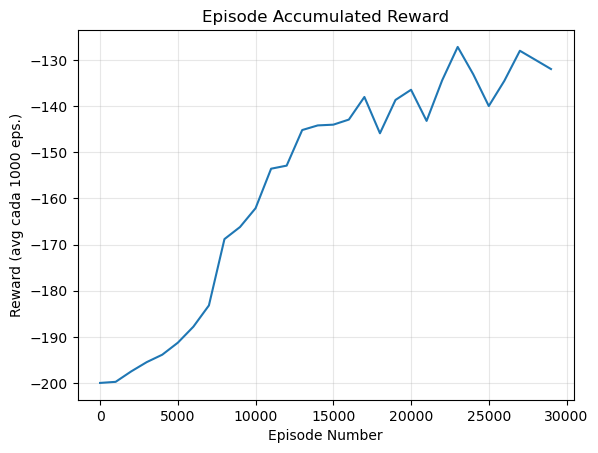

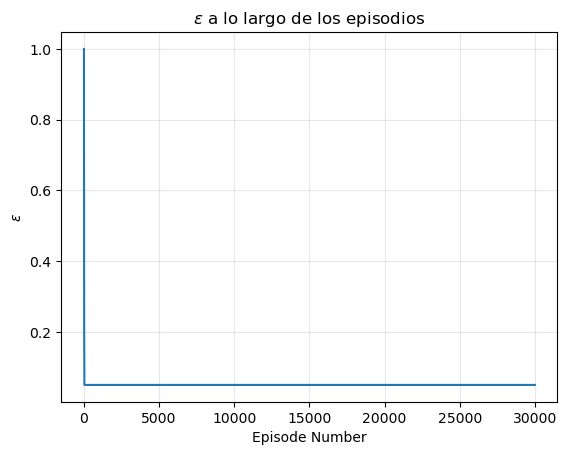

In [44]:
plot_rewards(rewards_dq)
plot_epsilon(epsilons_dq)

In [24]:
DYNA_Q_VIDEO_TEST = "./videos/dyna_q__test"
env_dis = get_env_discretized(record_video=True, record_every=1, folder=DYNA_Q_VIDEO_TEST)

for episode_num in range(5):
    (pos, vel), info = env_dis.reset()
    episode_over = False
    while not episode_over:
        action = np.argmax(Q_dq[pos, vel])  # Exploit
        (pos, vel), reward, terminated, truncated, info = env_dis.step(action)
        episode_over = terminated or truncated

/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/rodrigobenitez/Documents/GitHub/ORT-AI/Taller Inteligencia Artificial/Clases/Laboratorio 6 - Dyna-Q/videos/dyna_q__test folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [25]:
# Ruta al archivo de vídeo en tu sistema de ficheros
video_path = DYNA_Q_VIDEO_TEST + "/MountainCar-episode-0.mp4"

# Muestra el vídeo
Video(video_path, embed=True, width=600)

## Tareas

- Comparar el rendimiento de Dyna-Q con Q-learning en el entorno MountainCar.


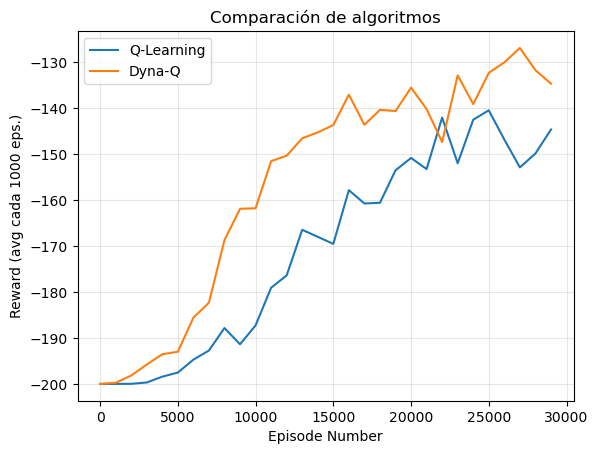

In [26]:
plot_rewards_comparison([rewards_ql, rewards_dq], ["Q-Learning", "Dyna-Q"])

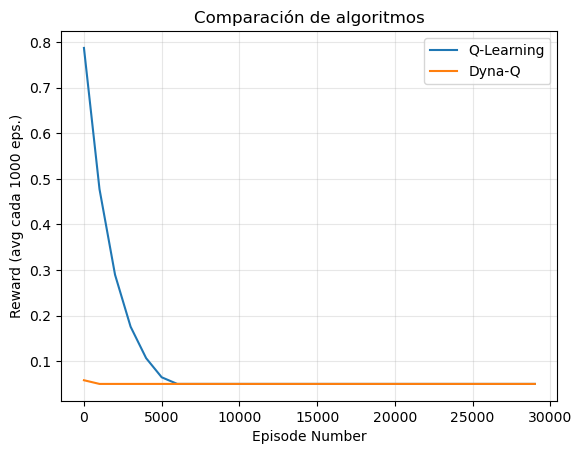

In [27]:
plot_rewards_comparison([epsilons_ql, epsilons_dq], ["Q-Learning", "Dyna-Q"])

*Comentario: Cambié "epsilon_decay" de Dyna-Q para que comparación de epsilon se notara en gráfico. 

Dyna-Q aprende significativamente más rápido que Q-Learning. A los 10.000 episodios, Dyna-Q ya alcanza -160 mientras Q-Learning sigue en -190. Al final ambos convergen cerca de -130 a -145 pero Dyna-Q llega antes.

- Tomar otro entorno de OpenAI Gymnasium y aplicar Dyna-Q.

Entorno seleccionado: Taxi-v3

El taxi debe recoger un pasajero y dejarlo en el destino correcto. 
Recompensas: -1 por paso, +20 al completar entrega, -10 por pickup/dropoff

In [29]:
# 1. Función para crear el entorno

def get_taxi_env(record_video=False, record_every=1, folder="./videos"):
    env = gym.make("Taxi-v3", render_mode="rgb_array")
    if record_video:
        env = RecordVideo(env, video_folder=folder, name_prefix="Taxi",
                          episode_trigger=lambda x: x % record_every == 0,
                          disable_logger=True)
    return env

In [30]:
#2. Video con acciones aleatorias

env_taxi = get_taxi_env(record_video=True, record_every=1, folder="./videos/taxi_random")
for _ in range(3):
    obs, _ = env_taxi.reset()
    done = False
    while not done:
        action = env_taxi.action_space.sample()
        obs, reward, terminated, truncated, _ = env_taxi.step(action)
        done = terminated or truncated
env_taxi.close()

Video("./videos/taxi_random/Taxi-episode-0.mp4", embed=True, width=400)

In [33]:
# 3. Acción greedy para Taxi

def select_action_taxi(env, Q, state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return random_argmax(Q[state])

In [39]:
# 4. Dyna-Q para Taxi

def dyna_q_taxi(env, num_episodes=5000, alpha=0.1, p_alpha=0.05, gamma=0.99, n=10,
                epsilon_start=1.0, epsilon_decay=0.999, epsilon_min=0.05):
    """
    Dyna-Q adaptado a Taxi-v3 (estado discreto nativo, sin discretización).

    Diferencias respecto a dyna_q() para MountainCar:
    - estado: entero en {0,...,499} en lugar de par (pos, vel).
    - Q-tabla: shape (n_states, n_actions) en lugar de (NUMBER_STATES, NUMBER_STATES, n_actions).

    Args:
        env          : ambiente Taxi-v3.
        num_episodes : cantidad de episodios de entrenamiento.
        alpha        : tasa de aprendizaje del paso real, en (0, 1].
        p_alpha      : tasa de aprendizaje de los pasos de planning, en (0, 1].
        gamma        : factor de descuento, en (0, 1].
        n            : cantidad de pasos de planning por paso real.
        epsilon_start: epsilon inicial (mas exploracion).
        epsilon_decay: factor multiplicativo aplicado por episodio.
        epsilon_min  : piso de epsilon (no decae por debajo).

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (n_states, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio.
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(list)
    epsilon = epsilon_start
    episode_rewards, epsilons = [], []

    pbar = tqdm(range(num_episodes), desc="Dyna-Q Taxi")
    for ep in pbar:
        state, _ = env.reset()
        done = False
        episode_reward = 0.0
        while not done:
            action = select_action_taxi(env, Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward

            # Aprendizaje directo (igual que Q-learning)
            td_target = reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha * (td_target - Q[state, action])

            # Aprendizaje del modelo: guardar la transición observada
            model[(state, action)].append((next_state, reward))

            # Planning: n actualizaciones de Q sobre transiciones muestreadas del modelo
            observed = list(model.keys())
            for _ in range(n):
                p_state, p_action = random.choice(observed)
                p_next_state, p_reward = random.choice(model[(p_state, p_action)])
                td_target_p = p_reward + gamma * np.max(Q[p_next_state])
                Q[p_state, p_action] += p_alpha * (td_target_p - Q[p_state, p_action])

            state = next_state
            done = terminated or truncated

        episode_rewards.append(episode_reward)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep + 1) % 50 == 0:
            recent = np.mean(episode_rewards[-100:])
            pbar.set_postfix(reward=f"{recent:.1f}", eps=f"{epsilon:.3f}")

    return Q, episode_rewards, epsilons

Dyna-Q Taxi: 100%|██████████| 5000/5000 [00:09<00:00, 521.68it/s, eps=0.050, reward=5.7]  


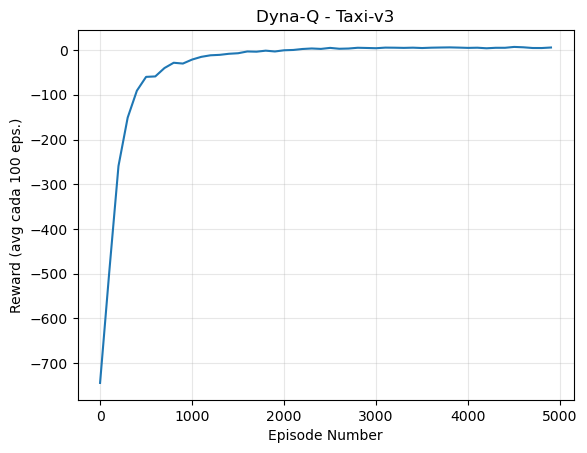

In [40]:
# 5. Entrenamiento + gráfico

TAXI_EPISODES = 5_000

env_taxi = get_taxi_env(record_video=True, record_every=1_000, folder="./videos/taxi_training")
Q_taxi, rewards_taxi, epsilons_taxi = dyna_q_taxi(env_taxi, num_episodes=TAXI_EPISODES, n=10)
env_taxi.close()

plot_rewards(rewards_taxi, average_range=100, title="Dyna-Q - Taxi-v3")

In [41]:
# 6. Video del agente entrenado

TAXI_TEST_FOLDER = "./videos/taxi_test"
env_taxi = get_taxi_env(record_video=True, record_every=1, folder=TAXI_TEST_FOLDER)

for _ in range(3):
    state, _ = env_taxi.reset()
    done = False
    while not done:
        action = np.argmax(Q_taxi[state])  # exploit
        state, _, terminated, truncated, _ = env_taxi.step(action)
        done = terminated or truncated
env_taxi.close()

Video(TAXI_TEST_FOLDER + "/Taxi-episode-0.mp4", embed=True, width=400)

/opt/miniconda3/envs/obl_taller_ia/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/rodrigobenitez/Documents/GitHub/ORT-AI/Taller Inteligencia Artificial/Clases/Laboratorio 6 - Dyna-Q/videos/taxi_test folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
